# Test App

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [47]:
import calendar

import pandas as pd
import numpy as np
import ocha_stratus as stratus
import matplotlib.pyplot as plt

from src.datasources import seas5, era5, emdat

## Set parameters

In [252]:
pcode = "ET"
issued_month = 5
valid_months = [7, 8, 9]
disaster_type = "Flood"
impact_col = "Total Affected"

In [253]:
if len(valid_months) < 3:
    valid_mo_str = "-".join([calendar.month_abbr[x] for x in valid_months])
else:
    valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

issued_mo_str = calendar.month_abbr[issued_month]

In [254]:
query = f"SELECT * FROM public.polygon WHERE pcode = '{pcode}'"
df_adm = pd.read_sql(query, stratus.get_engine(stage="prod"))
adm_name, iso3, adm_level = df_adm.iloc[0][["name", "iso3", "adm_level"]]
if adm_level > 0:
    query = (
        f"SELECT * FROM public.polygon WHERE iso3 = '{iso3}' AND adm_level = 0"
    )
    df_adm0 = pd.read_sql(query, stratus.get_engine(stage="prod"))
    adm0_name = df_adm0.iloc[0]["name"]
    adm_name_str = f"{adm_name} ({adm0_name})"
else:
    adm_name_str = adm_name
adm_name_str

'Ethiopia'

## Load data

### SEAS5

In [244]:
df_seas5 = seas5.load_seas5_yearly(
    pcode=pcode, issued_month=issued_month, valid_months=valid_months
)

### ERA5

In [269]:
df_era5 = era5.load_era5_yearly(pcode=pcode, valid_months=valid_months)
df_era5_full = era5.load_era5(pcode=pcode, valid_months=range(1, 13))

In [271]:
max_full_year = df_era5_full["valid_date"].dt.year.max() - 1
df_era5_monthly = (
    df_era5_full[df_era5_full["valid_date"].dt.year <= max_full_year]
    .groupby(df_era5_full["valid_date"].dt.month)["mean"]
    .mean()
    .reset_index()
)

In [277]:
df_era5_monthly["valid_month_str"] = df_era5_monthly["valid_date"].apply(
    lambda x: calendar.month_abbr[x]
)

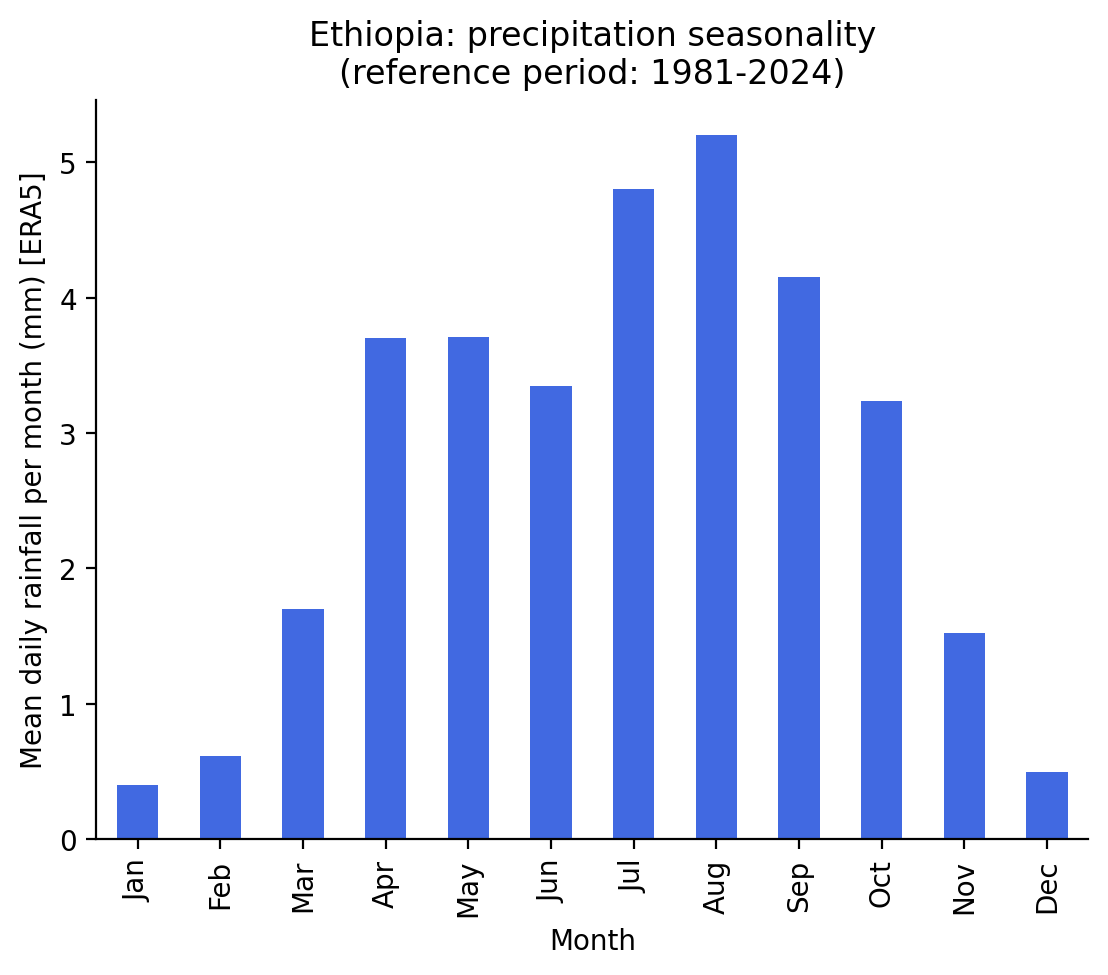

In [296]:
fig, ax = plt.subplots(dpi=200)
df_era5_monthly.plot.bar(
    x="valid_month_str", y="mean", legend=False, ax=ax, color="royalblue"
)
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily rainfall per month (mm) [ERA5]")
ax.set_title(
    f"{adm_name_str}: precipitation seasonality\n"
    f"(reference period: {df_era5_full['valid_date'].dt.year.min()}-{max_full_year})"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

### EM-DAT

In [246]:
df_emdat = emdat.load_emdat_yearly(
    iso3=iso3, disaster_type=disaster_type, col=impact_col
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Combine datasets

In [247]:
df_compare = df_seas5.merge(
    df_era5, on="year", how="outer", suffixes=("_seas5", "_era5")
).merge(df_emdat, how="outer")

## Plotting

In [255]:
col_to_label = {
    "mean_detrended_seas5": "Forecasted mean daily rainfall, detrended, "
    f"issued {issued_mo_str} (mm) [SEAS5]",
    "mean_detrended_era5": "Observed mean daily rainfall, detrended (mm) [ERA5]",
}

In [249]:
high_color = "royalblue"

In [250]:
def plot_comparison(
    df,
    xcol,
    ycol,
    colorcol=None,
    sizecol=None,
    rotation=0,
    min_year=None,
    title=None,
):
    df_ref = df.dropna(subset=[xcol, ycol])
    ref_min_year = df_ref["year"].min()
    ref_max_year = df_ref["year"].max()
    x_thresh, y_thresh = df_ref[[xcol, ycol]].quantile(2 / 3)

    if min_year is not None:
        df = df[df["year"] >= min_year]
    df = df.copy()

    xmax, ymax = df[[xcol, ycol]].max()
    xmin, ymin = df[[xcol, ycol]].min()
    padding = 0.1
    xrange = xmax - xmin
    yrange = ymax - ymin
    xlim = (xmin - padding * xrange, xmax + padding * xrange)
    ylim = (ymin - padding * yrange, ymax + padding * yrange)

    fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

    ax.axvspan(xmin=x_thresh, xmax=xlim[1], facecolor=high_color, alpha=0.1)
    ax.axhspan(ymin=y_thresh, ymax=ylim[1], facecolor=high_color, alpha=0.1)

    if sizecol is None:
        sizes = np.full(len(df), 0)
    else:
        sizes = df[sizecol].fillna(0) / df[sizecol].max() * 2000

    if colorcol is None:
        df["color"] = "k"
    else:
        df["color"] = df[colorcol].map({True: "crimson", False: "royalblue"})

    scatter = ax.scatter(
        df[xcol], df[ycol], s=sizes, c=df["color"], alpha=0.3, edgecolor="none"
    )

    for year, row in df.set_index("year").iterrows():
        ax.annotate(
            str(year),
            (row[xcol], row[ycol]),
            fontsize=8,
            ha="center",
            va="center",
            color=row["color"],
            rotation=rotation,
        )

    if "seas5" in xcol:
        current_val = df.set_index("year").loc[2025][xcol]
        ax.axvline(
            current_val,
            color="mediumorchid",
            linestyle="--",
        )
        ax.annotate(
            " 2025 forecast",
            (current_val, ylim[0]),
            rotation=90,
            va="bottom",
            ha="right",
            color="mediumorchid",
        )

    ax.set_xlabel(col_to_label.get(xcol, xcol))
    ax.set_ylabel(col_to_label.get(ycol, ycol))

    if title is not None:
        ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    return fig, ax

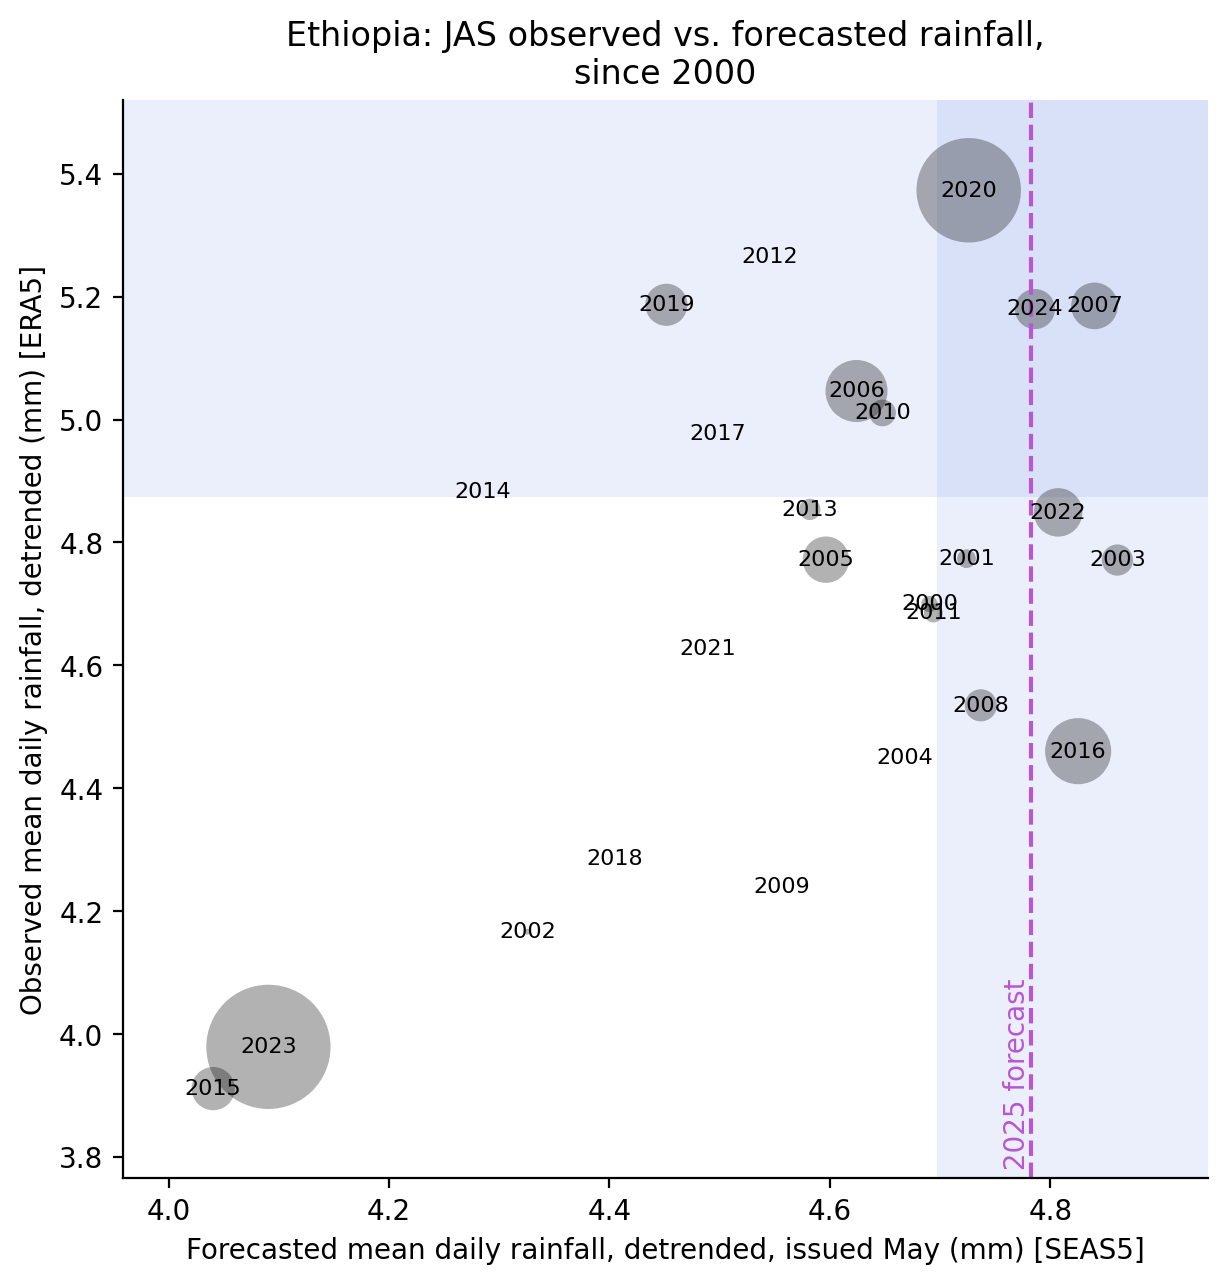

In [261]:
min_year = 2000
fig, ax = plot_comparison(
    df_compare,
    xcol="mean_detrended_seas5",
    ycol="mean_detrended_era5",
    sizecol="Total Affected",
    title=f"{adm_name}: {valid_mo_str} observed vs. forecasted rainfall,\n"
    f"since {min_year}",
    min_year=min_year,
)